# AI Clustering

> Concepts and demos

In [24]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Set plot style
sns.set_theme(style="darkgrid")

### What is Clustering?
Clustering is an **Unsupervised Machine Learning** technique. Unlike supervised learning (such as classification), we don't have labeled data (no "correct answers"). The algorithm's job is to discover hidden patterns and group similar data points together.

### Real-world Applications
* **Customer Segmentation:** Grouping buyers with similar purchasing habits. 🎯 
* **Anomaly Detection:** Finding outliers (e.g., credit card fraud). 🚨 
* **Biology:** Grouping genes with similar expression patterns. 🧬 

### How K-Means Works (The Intuition)
1. Pick $K$ random points as the initial "centers" (centroids) of our clusters.
2. Assign every data point to its closest centroid (usually measuring the **Euclidean Distance**).
3. Recalculate the center of each cluster based on the points assigned to it.
4. Repeat steps 2 and 3 until the centroids stop moving!

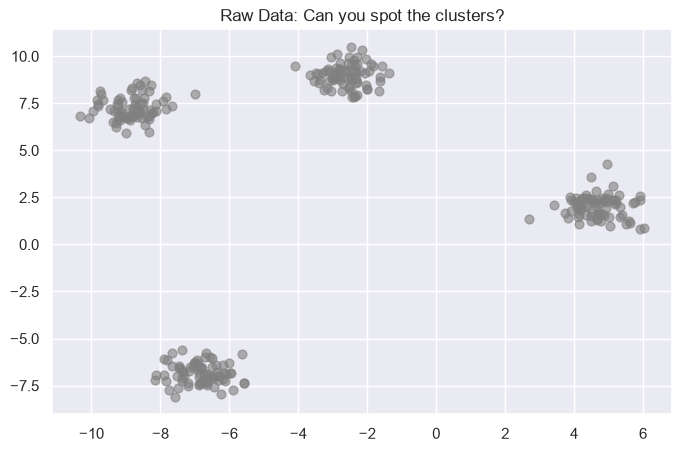

In [25]:
# 1. Generating synthetic 2D data for our basic example
# We create 300 points distributed around 4 centers
x_basic, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Let's plot the raw data (as the algorithm sees it: no colors, no labels)
plt.figure(figsize=(8, 5))
plt.scatter(x_basic[:, 0], x_basic[:, 1], s=40, color='gray', alpha=0.6)
plt.title("Raw Data: Can you spot the clusters?")
plt.show()

### Let's Apply K-Means!
Now, let's unleash the algorithm to find these 4 clusters automatically.

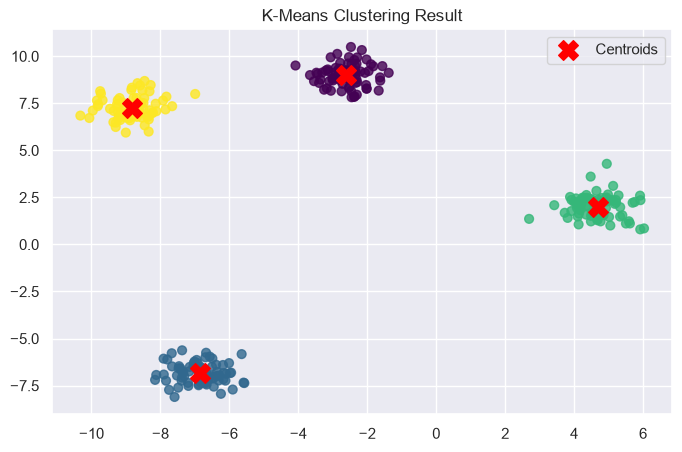

In [26]:
# 2. Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(x_basic)

# 3. Get the predicted clusters and the centroids
predicted_clusters = kmeans.predict(x_basic)
centroids = kmeans.cluster_centers_

# 4. Visualize the result
plt.figure(figsize=(8, 5))
plt.scatter(x_basic[:, 0], x_basic[:, 1], c=predicted_clusters, s=40, cmap='viridis', alpha=0.8)

# Plotting the centroids as red 'X's
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering Result")
plt.legend()
plt.show()

---
## Part 2: Under the Hood of Modern AI 🧠

If clustering groups points based on math and distance, how can we group **texts**, **images**, or **concepts**? Algorithms don't understand words; they only understand numbers.

### Enter: Embeddings
An Embedding is a translation. A Neural Network reads a sentence and translates its *semantic meaning* into a dense vector (a long list of numbers). 
* Sentences with similar meanings get vectors that are close to each other in this multidimensional space.

Let's see this in action using a real AI model!

In [31]:
from sentence_transformers import SentenceTransformer

# Load a lightweight, pre-trained AI model to generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

# Let's create a dataset of sentences from 3 different topics
sentences = [
    # Technology
    "Python is a great programming language.",
    "Machine learning algorithms are evolving fast.",
    # Sports
    "The striker scored a beautiful goal in the final.",
    "Basketball requires a lot of stamina and teamwork.",
    # Food
    "I love eating pepperoni pizza.",
    "A good pasta recipe needs fresh tomatoes."
]

# The AI translates sentences into mathematical coordinates (Embeddings)
embeddings = model.encode(sentences, device='cpu')

print(f"Number of sentences: {len(sentences)}")
print(f"Dimensions of each embedding vector: {embeddings.shape[1]}")
print(f"Preview of the first 5 numbers of the first sentence: \n{embeddings[0][:5]}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3484.43it/s]


Number of sentences: 6
Dimensions of each embedding vector: 384
Preview of the first 5 numbers of the first sentence: 
[-0.04332082 -0.01994371 -0.00669561 -0.00599781 -0.06033064]


### Semantic Clustering
Now we have 384-dimensional vectors! We can use the exact same K-Means algorithm we learned in Part 1 to group these sentences by their *meaning*.

In [32]:
# Apply K-Means to our 384-dimensional text embeddings
kmeans_nlp = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_nlp.fit(embeddings)

# Print the results grouped by their cluster
clusters = {0: [], 1: [], 2: []}
for sentence, cluster_id in zip(sentences, kmeans_nlp.labels_):
    clusters[cluster_id].append(sentence)

print("Semantic Grouping Results:\n")
for cluster_id, cluster_sentences in clusters.items():
    print(f"Cluster {cluster_id}:")
    for s in cluster_sentences:
        print(f" - {s}")
    print()

Semantic Grouping Results:

Cluster 0:
 - The striker scored a beautiful goal in the final.

Cluster 1:
 - I love eating pepperoni pizza.
 - A good pasta recipe needs fresh tomatoes.

Cluster 2:
 - Python is a great programming language.
 - Machine learning algorithms are evolving fast.
 - Basketball requires a lot of stamina and teamwork.



### Visualizing High Dimensions (PCA)
We humans can only see in 2D or 3D, but our embeddings live in a 384-dimensional space. To visualize our semantic clusters, we use a technique called **PCA (Principal Component Analysis)** to squash the 384 dimensions down to just 2, preserving as much information as possible.

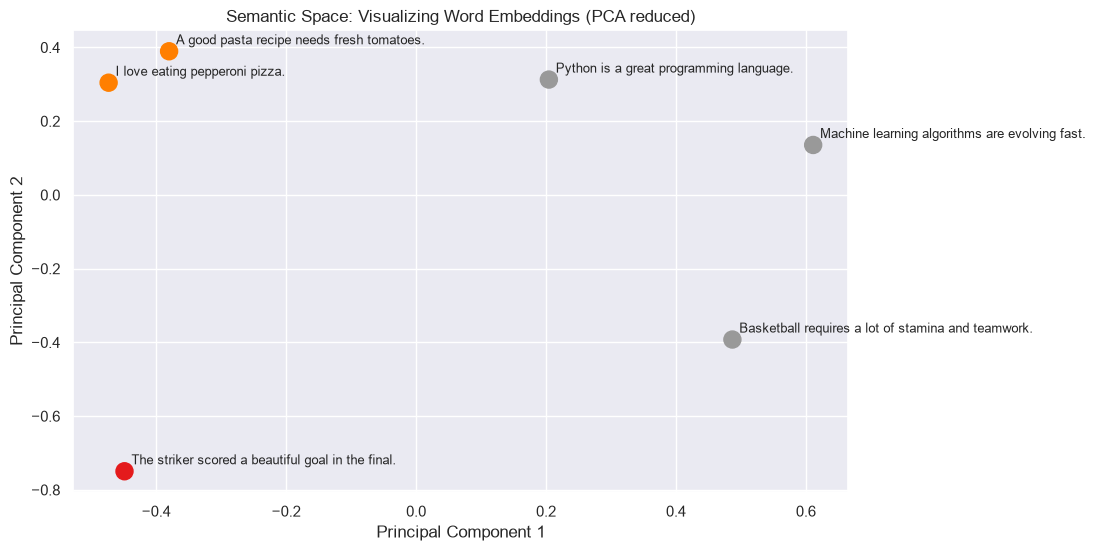

In [33]:
from sklearn.decomposition import PCA

# Reduce 384 dimensions down to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot the semantic clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                      c=kmeans_nlp.labels_, cmap='Set1', s=150)

# Add the actual sentences as labels to the points
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, 
                 (reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title("Semantic Space: Visualizing Word Embeddings (PCA reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### The Big Picture: Vector Databases 🚀
Why does this matter today?

When you ask ChatGPT a question over your company's documents, or when Spotify recommends a song, they are using **Vector Databases** (like Pinecone, Milvus, or ChromaDB). 

These databases don't search by keywords. They convert your search into an **Embedding**, and then use advanced clustering techniques (like *Inverted File Index*) to instantly find the "cluster" of documents that are mathematically closest to your question.

**Clustering is no longer just for data analysis; it's the engine powering modern AI retrieval!**